In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.animation as animation

# Homework 4: Animation

This assignment is the length of a lab but more like a homework in intent. The objective is to visualize the change in life expectancy over time. To do so, you will create three figures: a static image of the kind we're using to making, a .gif representing life expectancy evolving over time, and then a more sophisticated version of the animated .gif.

As always, ensure all of your figures are appropriately labeled.

## Global life expectancy over time

The following data represent average life expectancy from birth in a country in a given year.

In [3]:
le = pd.read_csv("life-expectancy.csv")
le.head()

,Entity,Code,Year,Life Expectancy
0,Afghanistan,AFG,1950,28.1563
1,Afghanistan,AFG,1951,28.5836
2,Afghanistan,AFG,1952,29.0138
3,Afghanistan,AFG,1953,29.4521
4,Afghanistan,AFG,1954,29.6975


These data represent the region of the world associated with each country.

In [4]:
continents = pd.read_csv("continents-according-to-our-world-in-data.csv")
continents.head()

,Entity,Code,Year,World regions
0,Afghanistan,AFG,2023,Asia
1,Aland Islands,ALA,2023,Europe
2,Albania,ALB,2023,Europe
3,Algeria,DZA,2023,Africa
4,American Samoa,ASM,2023,Oceania


#### Question 1

We'd like to visualize change in life expectancy by region. Combine the two datasets so that Life Expectancy and World Regions according to OWID are in the same DataFrame.

In [68]:
combine = le.merge(continents[['Entity', 'Code', 'World regions']],
                   on = ['Entity', 'Code'])
combine

,Entity,Code,Year,Life Expectancy,World regions
0,Afghanistan,AFG,1950,28.1563,Asia
1,Afghanistan,AFG,1951,28.5836,Asia
2,Afghanistan,AFG,1952,29.0138,Asia
3,Afghanistan,AFG,1953,29.4521,Asia
4,Afghanistan,AFG,1954,29.6975,Asia
...,...,...,...,...,...
19523,Zimbabwe,ZWE,2019,61.0603,Africa
19524,Zimbabwe,ZWE,2020,61.5300,Africa
19525,Zimbabwe,ZWE,2021,60.1347,Africa
19526,Zimbabwe,ZWE,2022,62.3601,Africa


#### Question 2

Create some sort of visualization that shows life expectancies by region with differences in time represented in some way. You could choose specific years to compare, average change etc... 

Irrespective, the figures in this assignment are open-ended. As long you meet the general criteria, you can create any kind of figure you'd like. You should also strive to make your figures both attractive, clear and correct.

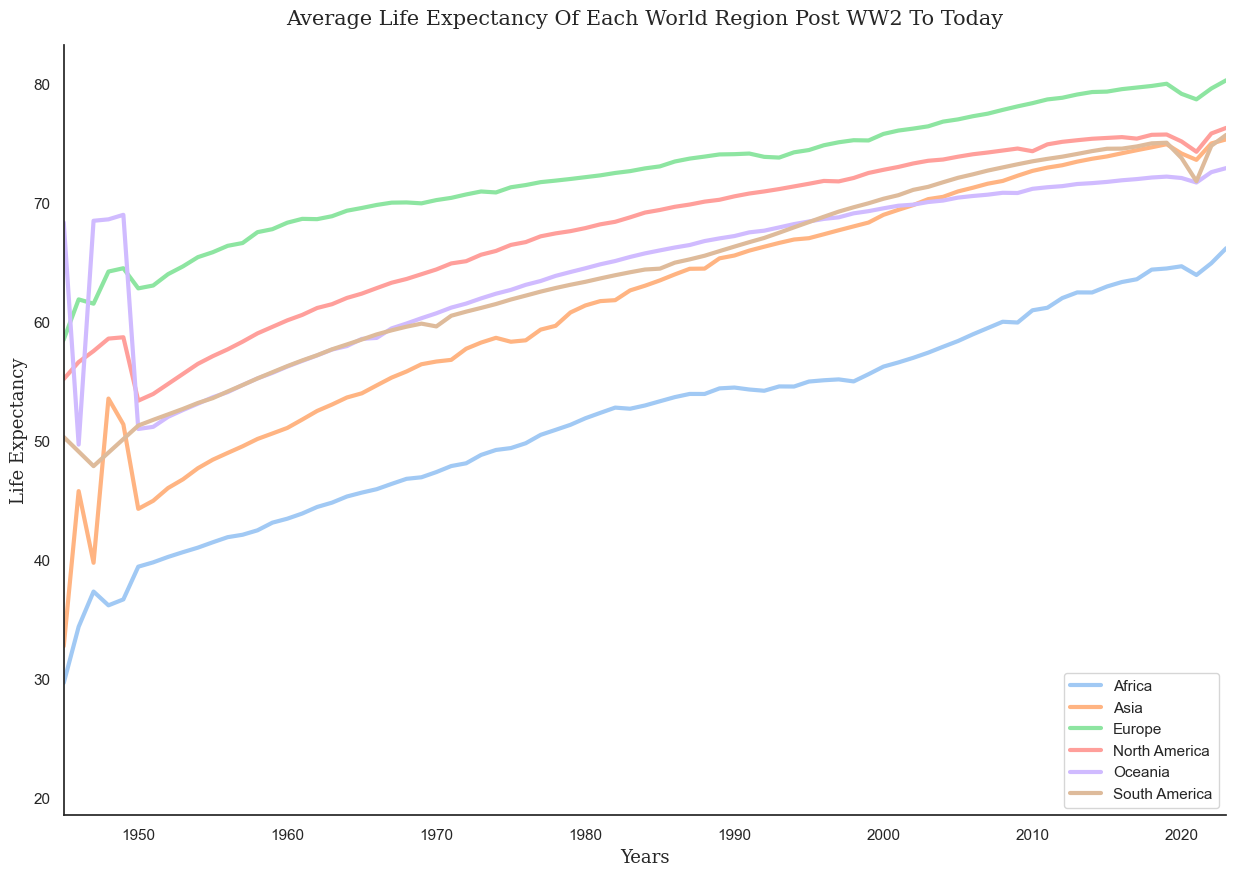

In [155]:
regions = combine.groupby(['World regions', 'Year'])['Life Expectancy'].mean().reset_index()
#group by region and year to get unique single values, then find the average life expectancy
# for that region 

fig, ax = plt.subplots(figsize = (15,10))

plt.grid(False)
sns.despine()

sns.lineplot(data = regions, x = 'Year', y = 'Life Expectancy', hue = 'World regions', linewidth = 3,
            palette = 'pastel')

plt.xlim(1945, 2023);


plt.title('Average Life Expectancy Of Each World Region Post WW2 To Today', 
          fontsize = 15, pad = 15, fontweight = 'light', fontfamily = 'serif');

plt.xlabel('Years', fontsize = 13, fontweight = 'light', fontfamily = 'serif');
plt.ylabel('Life Expectancy', fontsize = 13, fontweight = 'light', fontfamily = 'serif');

plt.legend(loc = 'lower right');

#### Question 3

Now create an animated .gif showing life expectancy in each region, where each frame is a year from 1950 to the latest date in the dataset. The life expectencies should have different colors based on region. Ultimately, the figure should convey a clear sense of evolving life expectencies over time.

In [246]:
import datetime

years = regions[regions['Year'] >= 1950]
dates = years['Year'].unique()
dates_sorted = dates[dates.argsort()]
dates_sorted

array([1950, 1951, 1952, 1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960,
       1961, 1962, 1963, 1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971,
       1972, 1973, 1974, 1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982,
       1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993,
       1994, 1995, 1996, 1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004,
       2005, 2006, 2007, 2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015,
       2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023])

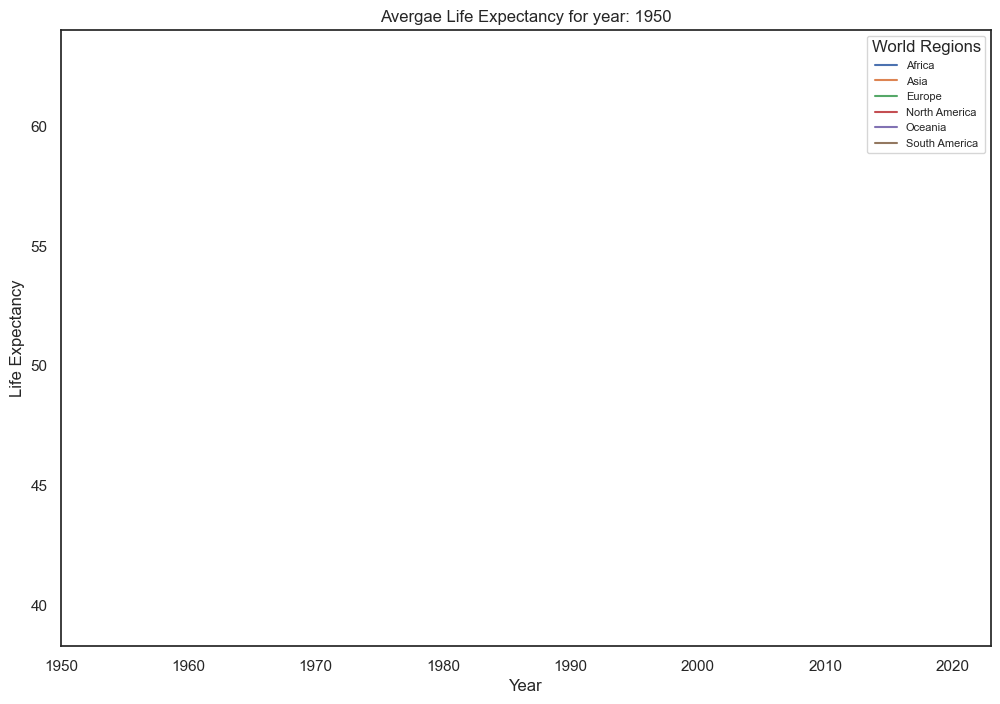

In [247]:
fig, ax = plt.subplots(figsize = (12, 8))

def update(dates):

    ax.clear()

    sns.lineplot(data = years[years['Year'] <= dates], ax = ax, x = 'Year', y = 'Life Expectancy', hue = 'World regions')
    ax.set_title(f'Plot {dates}')
    plt.xlim(1950, 2023)
    y_min = years['Life Expectancy'].min()
    y_max = years['Life Expectancy'].max()
    ax.set_title(f'Avergae Life Expectancy for year: {dates}')
    ax.set_ylabel('Life Expectancy')

    ax.legend(title = 'World Regions', loc = 'upper right', fontsize = 8)

ani = animation.FuncAnimation(fig, update, frames= dates_sorted, repeat=False)

MovieWriter imagemagick unavailable; using Pillow instead.


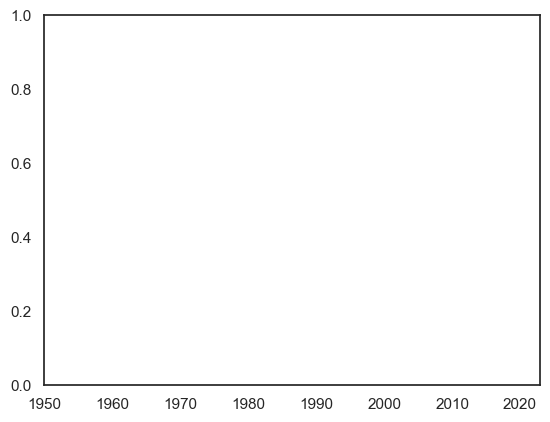

In [248]:
ani.save('Homework_4.gif', writer = 'imagemagick', fps = 4)

#### Question 4

Let's up our game a bit. Add some degree of "history" to the animated figure, where for every year of data plotted you can also see past years of data as well. In other words, your gif should now contain visual elements that emphasize not just the data in a given year but how it has evolved from previous years. The historical data should not overly distract from the current year's data.

Again, there are many ways to pull this off and I will feature the best figures in class.

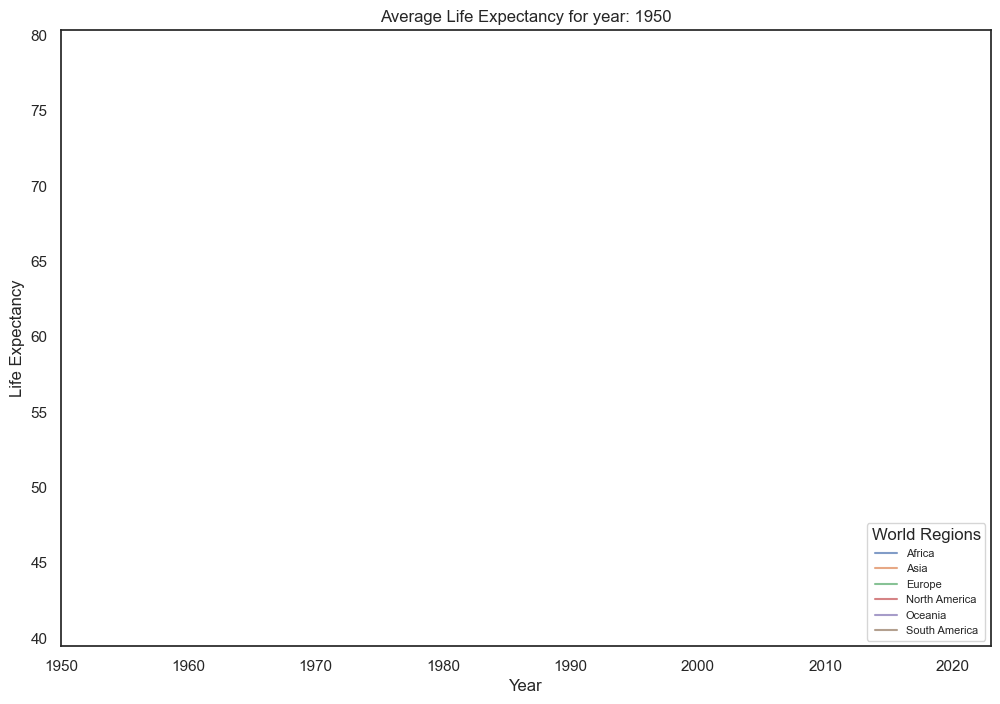

In [258]:
fig, ax = plt.subplots(figsize = (12, 8))

def update(dates):

    ax.clear()

    sns.lineplot(data = years[years['Year'] <= dates], ax = ax, x = 'Year', y = 'Life Expectancy', hue = 'World regions', alpha = 0.7)
    ax.set_title(f'Plot {dates}')
    
    ax.set_xlim(1950, 2023)
    ax.set_ylim(years['Life Expectancy'].min(), years['Life Expectancy'].max())
        
    ax.set_title(f'Average Life Expectancy for year: {dates}')
    ax.set_ylabel('Life Expectancy')
    
    ax.legend(title = 'World Regions', loc = 'lower right', fontsize = 8)

ani = animation.FuncAnimation(fig, update, frames= dates_sorted, repeat=False)

In [259]:
ani.save('Homework_4_part_2.gif', writer = 'imagemagick', fps = 4)

MovieWriter imagemagick unavailable; using Pillow instead.


That's it for this homework. You've now learned how to animate non-geospatial data in an open-ended way. Hopefully you came up with some clever way to demonstrate the change in global life expectancy through time. Please submit your .gif file and the code you generated it with to the relevant assignment on Canvas.